In [1]:
pip install numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

ModuleNotFoundError: No module named 'kagglehub'

In [4]:
df=pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [8]:
df.shape

(918, 12)

In [9]:
df.columns.tolist()

['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'Oldpeak',
 'ST_Slope',
 'HeartDisease']

In [11]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [16]:
print("Missing values pe column: \n", df.isnull().sum())

Missing values pe column: 
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [17]:
df=df.drop_duplicates()

In [21]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [19]:
text_cols = df.select_dtypes(include='object').columns
df[text_cols] = df[text_cols].fillna("Unknown")

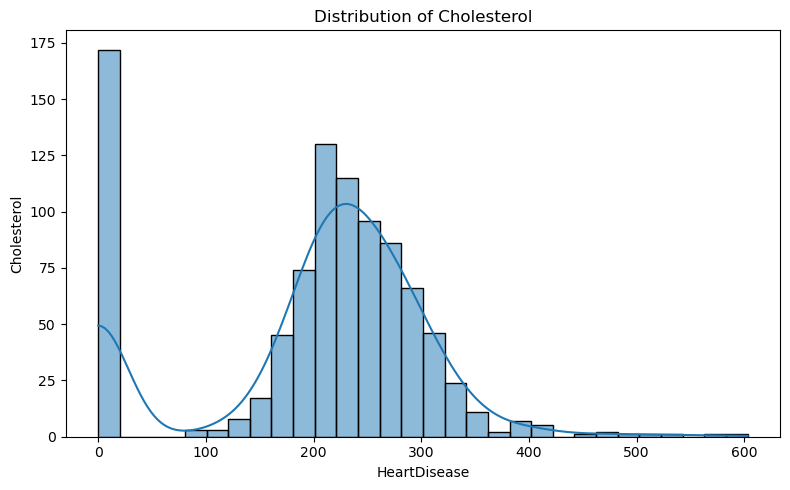

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df["Cholesterol"].dropna(), kde=True, bins=30)
plt.title(f'Distribution of {"Cholesterol"}')
plt.xlabel("HeartDisease")
plt.ylabel('Cholesterol')
plt.tight_layout()
plt.savefig(f'{"Cholesterol Graph"}_distribution.png')
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [28]:
def prepare_data(df, target='HeartDisease'):
    """Encode categorical columns and split into X (inputs) and y (output)."""
    df = df.copy()
    
    # Fix the Cholesterol=0 issue (0 means missing, not real value)
    df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
    df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())
    
    # Encode all text categories into numbers
    categorical_cols = df.select_dtypes(include='object').columns
    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le  # save so we can decode/encode new inputs later
    
    X = df.drop(columns=[target])
    y = df[target]
    
    return X, y, encoders

X, y, encoders = prepare_data(df)

In [29]:
def split_and_scale(X, y, test_size=0.2):
    """Split into train/test sets and scale numeric features."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

X_train, X_test, y_train, y_test, scaler = split_and_scale(X, y)

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def train_models(X_train, y_train, X_test, y_test):
    """Train several models and compare accuracy."""
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42)
    }
    
    results = {}
    trained_models = {}
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        results[name] = acc
        trained_models[name] = model
        print(f"{name}: {acc:.4f}")
    
    return trained_models, results

trained_models, results = train_models(X_train, y_train, X_test, y_test)

Logistic Regression: 0.8478
Decision Tree: 0.7663
Random Forest: 0.8587


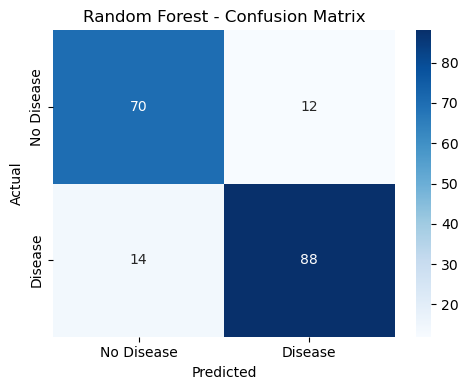


Random Forest Classification Report:

              precision    recall  f1-score   support

  No Disease       0.83      0.85      0.84        82
     Disease       0.88      0.86      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184

ROC-AUC Score: 0.9258


0.9258130081300814

In [31]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Full evaluation: confusion matrix, report, ROC curve."""
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    # Confusion matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'{model_name}_confusion_matrix.png')
    plt.show()
    
    # Text report: precision, recall, f1
    print(f"\n{model_name} Classification Report:\n")
    print(classification_report(y_test, preds, target_names=['No Disease', 'Disease']))
    
    # ROC-AUC score
    auc = roc_auc_score(y_test, probs)
    print(f"ROC-AUC Score: {auc:.4f}")
    
    return auc

best_model = trained_models['Random Forest']
evaluate_model(best_model, X_test, y_test, "Random Forest")

In [33]:
def predict_new_patient(model, scaler, encoders, patient_dict, feature_order):
    """Predict HeartDisease for a single new patient (as a dict)."""
    df_new = pd.DataFrame([patient_dict])
    
    # Encode categorical fields using the same encoders from training
    for col, le in encoders.items():
        if col in df_new.columns:
            df_new[col] = le.transform(df_new[col])
    
    df_new = df_new[feature_order]  # ensure same column order as training
    df_new_scaled = scaler.transform(df_new)
    
    prediction = model.predict(df_new_scaled)[0]
    probability = model.predict_proba(df_new_scaled)[0][1]
    
    result = "Disease" if prediction == 1 else "No Disease"
    print(f"Prediction: {result} (probability of disease: {probability:.2%})")
    return prediction

# Example usage
new_patient = {
    'Age': 55, 'Sex': 'M', 'ChestPainType': 'ASY', 'RestingBP': 140,
    'Cholesterol': 20, 'FastingBS': 0, 'RestingECG': 'Normal',
    'MaxHR': 120, 'ExerciseAngina': 'Y', 'Oldpeak': 1.5, 'ST_Slope': 'Flat'
}

predict_new_patient(best_model, scaler, encoders, new_patient, X.columns.tolist())

Prediction: Disease (probability of disease: 97.00%)


np.int64(1)

Logistic Regression: 0.8478
Decision Tree: 0.7663
Random Forest: 0.8587

🏆 Best model: Random Forest (0.8587 accuracy)


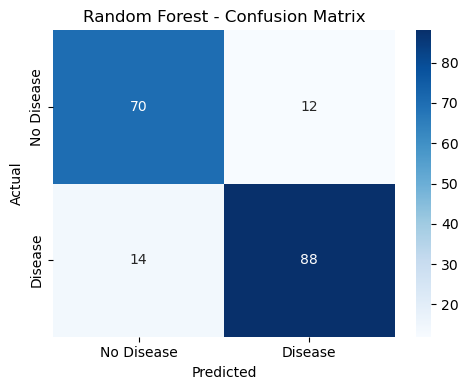


Random Forest Classification Report:

              precision    recall  f1-score   support

  No Disease       0.83      0.85      0.84        82
     Disease       0.88      0.86      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184

ROC-AUC Score: 0.9258


In [34]:
def run_ml_pipeline(df, target='HeartDisease'):
    """Complete ML pipeline: prepare → split → train → evaluate."""
    X, y, encoders = prepare_data(df, target)
    X_train, X_test, y_train, y_test, scaler = split_and_scale(X, y)
    trained_models, results = train_models(X_train, y_train, X_test, y_test)
    
    best_name = max(results, key=results.get)
    print(f"\n🏆 Best model: {best_name} ({results[best_name]:.4f} accuracy)")
    
    evaluate_model(trained_models[best_name], X_test, y_test, best_name)
    
    return trained_models[best_name], scaler, encoders, X.columns.tolist()

final_model, scaler, encoders, feature_order = run_ml_pipeline(df)